In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("whenamancodes/credit-card-customers-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'credit-card-customers-prediction' dataset.
Path to dataset files: /kaggle/input/credit-card-customers-prediction


In [10]:
import os
file_list = os.listdir(path)
file_path = os.path.join(path, file_list[0])
df = pd.read_csv(file_path)
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [11]:
df.head(5)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [13]:
df.describe()


,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990


In [14]:
df.isnull().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0


In [15]:
cat = df.select_dtypes(include="object")
for i in df:
  if i in cat:
        values = df[i].unique()
        print(f"name of col:--->{i}")
        print(f"datatype:-->{df[i].dtype}")
        print(f"values they have:--->{values}\n \n")

name of col:--->Attrition_Flag
datatype:-->object
values they have:--->['Existing Customer' 'Attrited Customer']
 

name of col:--->Gender
datatype:-->object
values they have:--->['M' 'F']
 

name of col:--->Education_Level
datatype:-->object
values they have:--->['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
 

name of col:--->Marital_Status
datatype:-->object
values they have:--->['Married' 'Single' 'Unknown' 'Divorced']
 

name of col:--->Income_Category
datatype:-->object
values they have:--->['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']
 

name of col:--->Card_Category
datatype:-->object
values they have:--->['Blue' 'Gold' 'Silver' 'Platinum']
 



In [16]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
# deleting non required columns
df.drop(['CLIENTNUM','Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1','Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],axis=1, inplace=True, errors='ignore')

In [19]:
# DATA VISUALIZATION
# 1 Column (Category)     → Countplot
# 1 Column (Numerical)    → Histogram
# Category vs Category    → Countplot + Hue
# Numerical vs Category   → Boxplot
# Numerical vs Numerical  → Scatter Plot
# All Numerical Features  → Heatmap
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [20]:
num_data = df.select_dtypes(include="int")
cat_data = df.select_dtypes(include="object")
display(num_data.head(3))
display(cat_data.head(3))

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Total_Revolving_Bal,Total_Trans_Amt,Total_Trans_Ct
0,45,3,39,5,1,3,777,1144,42
1,49,5,44,6,1,2,864,1291,33
2,51,3,36,4,1,0,0,1887,20


,Attrition_Flag,Gender,Education_Level,Marital_Status,Income_Category,Card_Category
0,Existing Customer,M,High School,Married,$60K - $80K,Blue
1,Existing Customer,F,Graduate,Single,Less than $40K,Blue
2,Existing Customer,M,Graduate,Married,$80K - $120K,Blue


In [21]:
# FOR NUMERICAL COLUMNS COMPARISON


<Axes: xlabel='Customer_Age', ylabel='Count'>

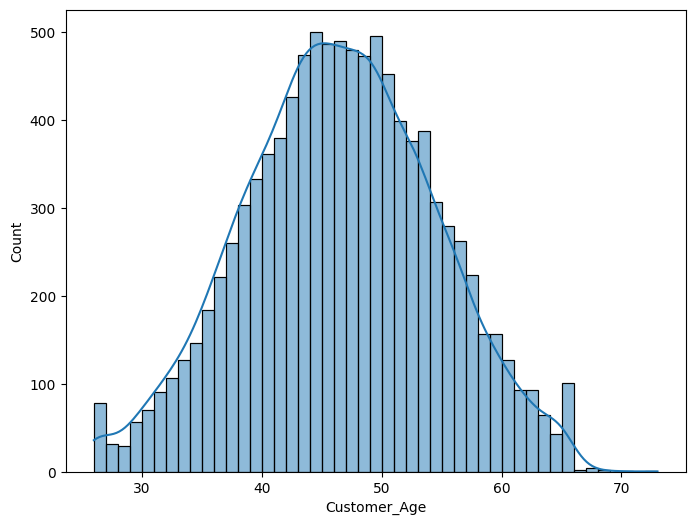

In [22]:

fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(data=df, x="Customer_Age", kde=True)

<Axes: xlabel='Dependent_count', ylabel='Count'>

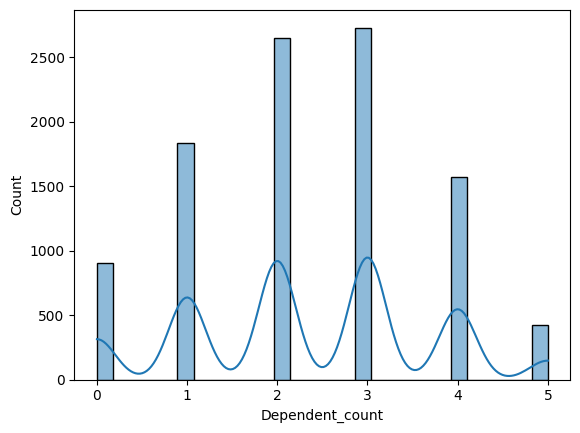

In [23]:
sns.histplot(data=df, x="Dependent_count", kde=True)

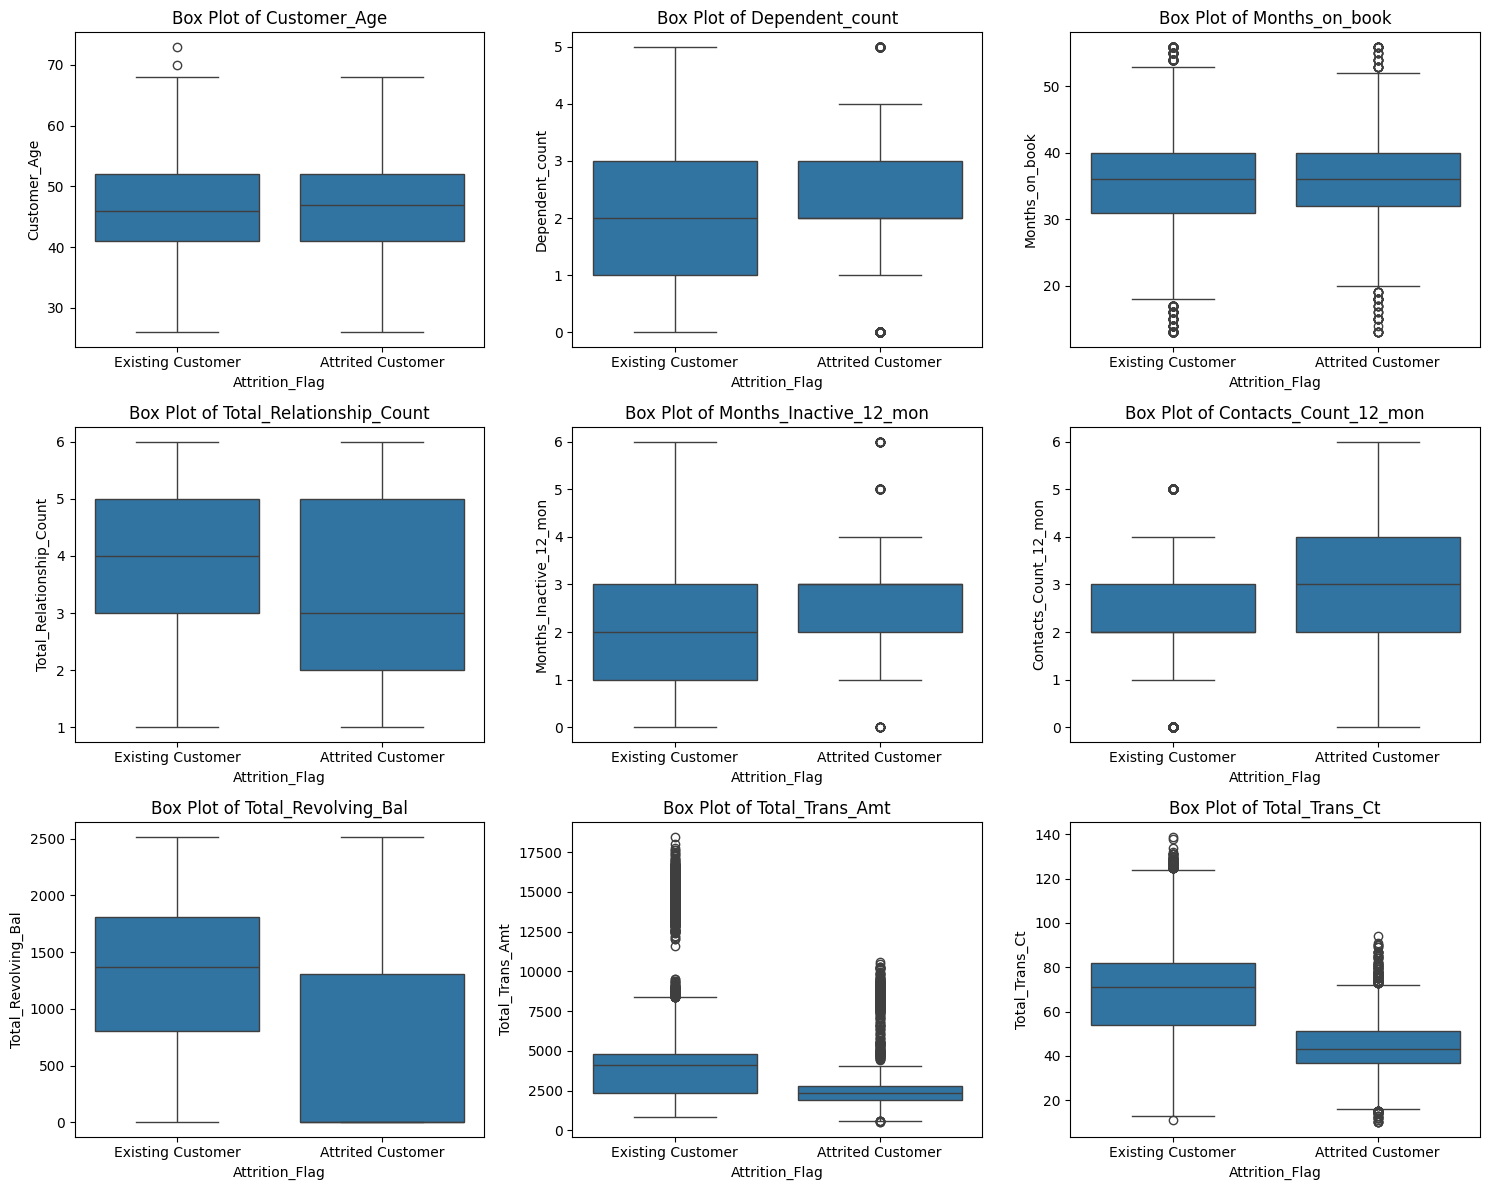

In [24]:
num_cols_to_plot = [col for col in df.columns if col in num_data.columns]
num_plots = len(num_cols_to_plot)

# Calculate grid size (e.g., 3 columns, adjust rows as needed)
n_cols = 3
n_rows = (num_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(num_cols_to_plot):
    sns.boxplot(data=df, x="Attrition_Flag", y=col, ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [25]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)
# DATA VISUALIZATION
# 1 Column (Category)     → Countplot
# 1 Column (Numerical)    → Histogram
# Category vs Category    → Countplot + Hue
# Numerical vs Category   → Boxplot
# Numerical vs Numerical  → Scatter Plot
# All Numerical Features  → Heatmap

Index(['Attrition_Flag', 'Gender', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category'],
      dtype='object')


In [26]:
cat = df.select_dtypes(include="object")
for i in df:
  if i in cat:
        values = df[i].unique()
        print(f"name of col:--->{i}")
        print(f"datatype:-->{df[i].dtype}")
        print(f"values they have:--->{values}\n \n")

name of col:--->Attrition_Flag
datatype:-->object
values they have:--->['Existing Customer' 'Attrited Customer']
 

name of col:--->Gender
datatype:-->object
values they have:--->['M' 'F']
 

name of col:--->Education_Level
datatype:-->object
values they have:--->['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
 

name of col:--->Marital_Status
datatype:-->object
values they have:--->['Married' 'Single' 'Unknown' 'Divorced']
 

name of col:--->Income_Category
datatype:-->object
values they have:--->['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']
 

name of col:--->Card_Category
datatype:-->object
values they have:--->['Blue' 'Gold' 'Silver' 'Platinum']
 



<Axes: xlabel='Attrition_Flag', ylabel='count'>

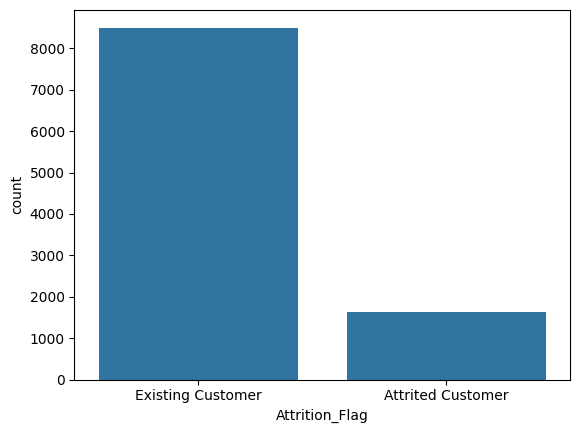

In [27]:
sns.countplot(data=df, x="Attrition_Flag")

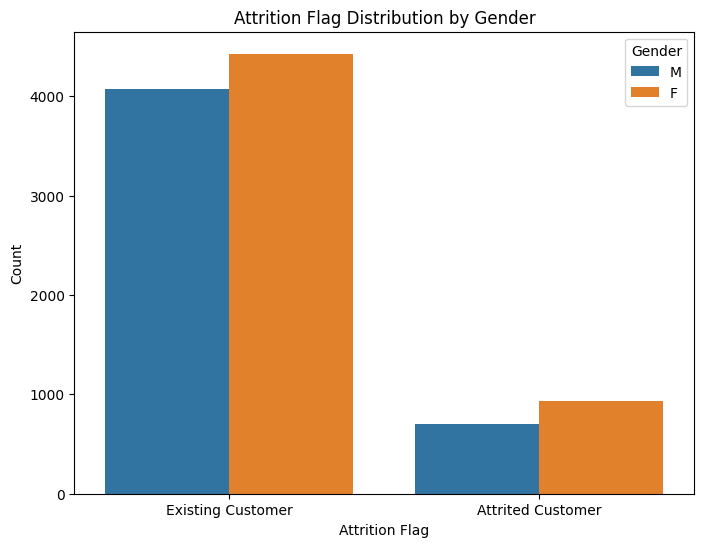

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(data=df, x="Attrition_Flag", hue="Gender", ax=ax)
plt.title('Attrition Flag Distribution by Gender')
plt.xlabel('Attrition Flag')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()

### Category vs. Category: Attrition_Flag by Education_Level

Let's analyze the relationship between `Attrition_Flag` and `Education_Level` using a countplot with `hue` to observe if attrition rates differ based on education.

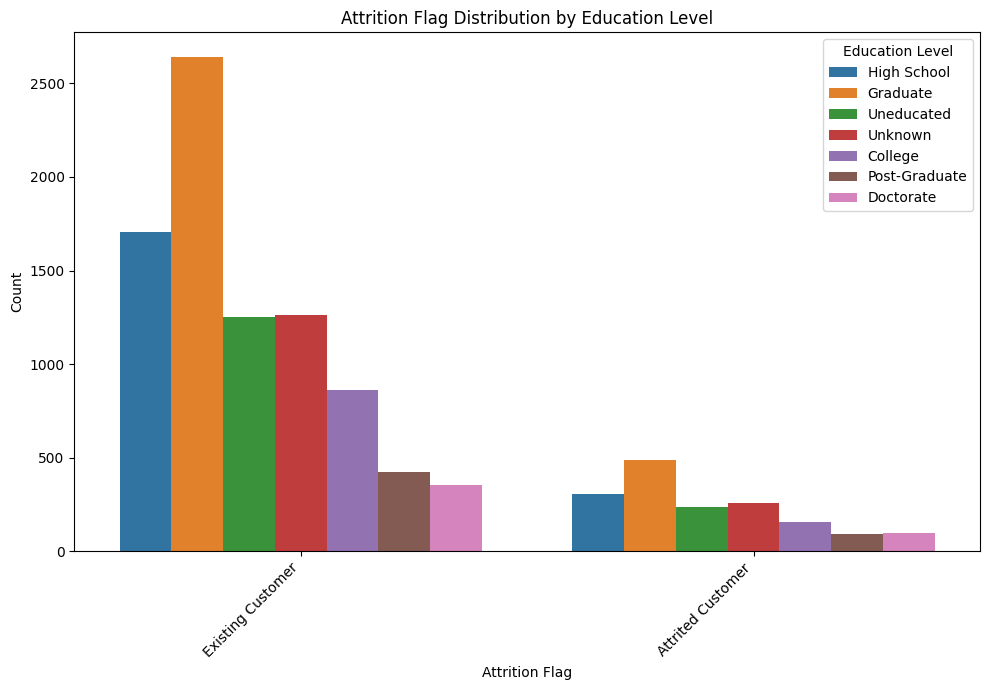

In [29]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.countplot(data=df, x="Attrition_Flag", hue="Education_Level", ax=ax)
plt.title('Attrition Flag Distribution by Education Level')
plt.xlabel('Attrition Flag')
plt.ylabel('Count')
plt.legend(title='Education Level')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [30]:
cat_cols = df.select_dtypes(include="object").columns.tolist()

In [31]:
cat_cols.remove("Attrition_Flag")

In [32]:
data = df.copy()

In [33]:
# label encoding on target column
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data["Attrition_Flag"] = le.fit_transform(data["Attrition_Flag"])



In [34]:
# spliting X and Y
X = data.drop('Attrition_Flag', axis=1)
y = data["Attrition_Flag"]

In [35]:
# TRAIN TESTING
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.20 ,random_state=42)

In [36]:
from sklearn.naive_bayes import GaussianNB

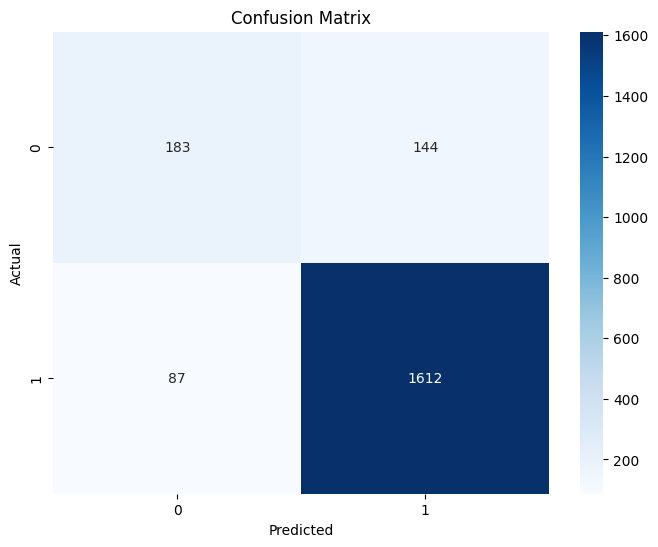

In [37]:
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = GaussianNB()

# Identify categorical columns that are still in X_train and X_test
# cat_cols was defined earlier and holds the list of categorical column names
cols_to_encode = [col for col in X_train.columns if X_train[col].dtype == 'object']

# One-hot encode the categorical columns in both training and testing sets
# drop_first=True is used to avoid multicollinearity
X_train_encoded = pd.get_dummies(X_train, columns=cols_to_encode, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=cols_to_encode, drop_first=True)

# Fit the model with the encoded training data
model.fit(X_train_encoded, y_train)

# Make predictions with the encoded testing data
y_predict = model.predict(X_test_encoded)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_predict), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [38]:
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy_score(y_test, y_predict)

0.8859822309970385

In [39]:
accuracy_score(y_train,model.predict(X_train_encoded))

0.897666954696951

In [40]:
# The confusion matrix is now plotted within the model training/prediction cell (u5GX6isuL8dE).

In [41]:
import joblib
joblib.dump(model,"naive.joblib")

['naive.joblib']